  state  account_length      area_code international_plan voice_mail_plan  \
0    KS             128  area_code_415                 no             yes   
1    OH             107  area_code_415                 no             yes   
2    NJ             137  area_code_415                 no              no   
3    OH              84  area_code_408                yes              no   
4    OK              75  area_code_415                yes              no   

   number_vmail_messages  total_day_minutes  total_day_calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   total_day_charge  total_eve_minutes  total_eve_calls  total_eve_charge  \
0             45.07              197.4               99             16.78  

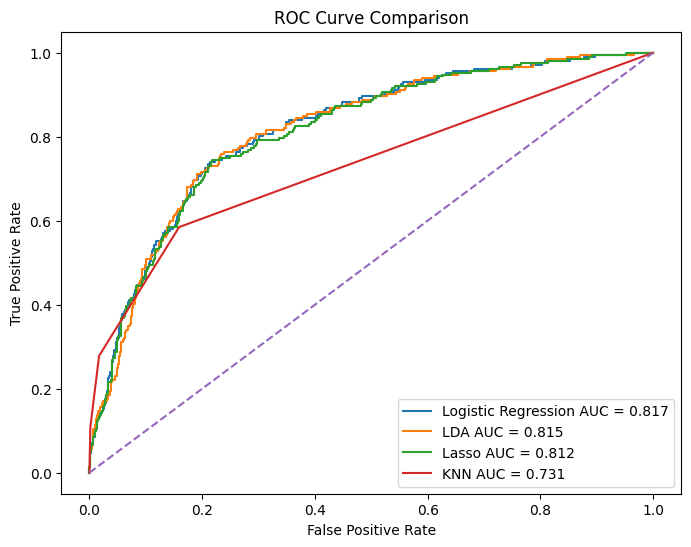

                       Model       AUC
0        Logistic Regression  0.816748
1                        LDA  0.815298
2  Lasso Logistic Regression  0.811929
3                        KNN  0.730735
The model with the highest AUC performed best at separating churn and non churn observations.
The best model based on AUC was: Logistic Regression
KNN was tuned using 10 fold cross validation, which satisfies the hyperparameter tuning requirement.


In [2]:
# Maximino Villanueva
# Week 4 Classification Models Assignment
# Python Version for Google Colab

# ---------------------------------------------
# Install Required Package
# ---------------------------------------------

!pip install statsmodels --quiet

# ---------------------------------------------
# Import Required Libraries
# ---------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

# ---------------------------------------------
# Data Loading
# ---------------------------------------------

churn_data = sm.datasets.get_rdataset("mlc_churn", "modeldata").data

print(churn_data.head())

print(churn_data.info())

# ---------------------------------------------
# Preprocessing
# ---------------------------------------------

churn_data = churn_data.dropna()

y = churn_data["churn"]

X = churn_data.drop(columns=["churn"])

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=123,
    stratify=y
)

# ---------------------------------------------
# Logistic Regression Model
# ---------------------------------------------

log_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_prob = log_model.predict_proba(X_test)[
    :,
    list(log_model.classes_).index("yes")
]

print("Logistic Regression Confusion Matrix")
print(confusion_matrix(y_test, log_pred))

print("Logistic Regression Classification Report")
print(classification_report(y_test, log_pred))

# ---------------------------------------------
# Linear Discriminant Analysis Model
# ---------------------------------------------

lda_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LinearDiscriminantAnalysis())
    ]
)

lda_model.fit(X_train, y_train)

lda_pred = lda_model.predict(X_test)

lda_prob = lda_model.predict_proba(X_test)[
    :,
    list(lda_model.classes_).index("yes")
]

print("LDA Confusion Matrix")
print(confusion_matrix(y_test, lda_pred))

print("LDA Classification Report")
print(classification_report(y_test, lda_pred))

# ---------------------------------------------
# Penalized Logistic Regression Model
# ---------------------------------------------

lasso_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegressionCV(
                Cs=10,
                cv=10,
                penalty="l1",
                solver="liblinear",
                max_iter=1000
            )
        )
    ]
)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

lasso_prob = lasso_model.predict_proba(X_test)[
    :,
    list(lasso_model.classes_).index("yes")
]

print("Lasso Logistic Regression Confusion Matrix")
print(confusion_matrix(y_test, lasso_pred))

print("Lasso Logistic Regression Classification Report")
print(classification_report(y_test, lasso_pred))

# ---------------------------------------------
# K Nearest Neighbors Model With Tuning
# ---------------------------------------------

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier())
    ]
)

knn_grid = {
    "classifier__n_neighbors": list(range(3, 26, 2))
}

knn_model = GridSearchCV(
    knn_pipeline,
    knn_grid,
    cv=10,
    scoring="accuracy"
)

knn_model.fit(X_train, y_train)

print("Best K for KNN")
print(knn_model.best_params_)

knn_pred = knn_model.predict(X_test)

knn_prob = knn_model.predict_proba(X_test)[
    :,
    list(knn_model.classes_).index("yes")
]

print("KNN Confusion Matrix")
print(confusion_matrix(y_test, knn_pred))

print("KNN Classification Report")
print(classification_report(y_test, knn_pred))

# ---------------------------------------------
# ROC Curve Analysis
# ---------------------------------------------

fpr_log, tpr_log, _ = roc_curve(
    y_test,
    log_prob,
    pos_label="yes"
)

fpr_lda, tpr_lda, _ = roc_curve(
    y_test,
    lda_prob,
    pos_label="yes"
)

fpr_lasso, tpr_lasso, _ = roc_curve(
    y_test,
    lasso_prob,
    pos_label="yes"
)

fpr_knn, tpr_knn, _ = roc_curve(
    y_test,
    knn_prob,
    pos_label="yes"
)

auc_log = auc(fpr_log, tpr_log)

auc_lda = auc(fpr_lda, tpr_lda)

auc_lasso = auc(fpr_lasso, tpr_lasso)

auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression AUC = {auc_log:.3f}"
)

plt.plot(
    fpr_lda,
    tpr_lda,
    label=f"LDA AUC = {auc_lda:.3f}"
)

plt.plot(
    fpr_lasso,
    tpr_lasso,
    label=f"Lasso AUC = {auc_lasso:.3f}"
)

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f"KNN AUC = {auc_knn:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve Comparison")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

# ---------------------------------------------
# Model Comparison Table
# ---------------------------------------------

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LDA",
        "Lasso Logistic Regression",
        "KNN"
    ],
    "AUC": [
        auc_log,
        auc_lda,
        auc_lasso,
        auc_knn
    ]
})

print(model_comparison)

# ---------------------------------------------
# Final Interpretation
# ---------------------------------------------

best_model = model_comparison.sort_values(
    by="AUC",
    ascending=False
).iloc[0]

print("The model with the highest AUC performed best at separating churn and non churn observations.")

print("The best model based on AUC was:", best_model["Model"])

print("KNN was tuned using 10 fold cross validation, which satisfies the hyperparameter tuning requirement.")